In [1]:
#Importing the necessary libraries
import requests
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# Data Aquisition Cell
# Define the location and parameters
# 27°32′23″N 71°54′55″E
# Bhadla Solar Park, Rajasthan, India
latitude = 27.5397
longitude = 71.9153
start_date = "20240101"  # Start date in YYYYMMDD format
end_date = "20240630"    # End date in YYYYMMDD format
parameters = "ALLSKY_SFC_SW_DWN,T2M,RH2M,WS2M,CLRSKY_SFC_SW_DWN"

# NASA POWER API base URL
# Retrieves daily data for the specified location and parameters
url = "https://power.larc.nasa.gov/api/temporal/daily/point"

# Request parameters
params = {
    "parameters": parameters,
    "community": "RE", # Renewable Energy community
    "longitude": longitude,
    "latitude": latitude,
    "start": start_date,
    "end": end_date,
    "format": "JSON"
}

# Send the API request
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    data = response.json()  # Parse the JSON response
    print("Hourly Data:")
    print(data)
else:
    print(f"Failed to retrieve data: {response.status_code}")

Hourly Data:
{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [71.9153, 27.5397, 177.4]}, 'properties': {'parameter': {'ALLSKY_SFC_SW_DWN': {'20240101': 2.73, '20240102': 3.34, '20240103': 3.14, '20240104': 2.74, '20240105': 3.25, '20240106': 3.6, '20240107': 2.99, '20240108': 1.61, '20240109': 3.46, '20240110': 4.11, '20240111': 4.36, '20240112': 4.43, '20240113': 4.19, '20240114': 3.07, '20240115': 4.11, '20240116': 4.03, '20240117': 3.03, '20240118': 3.56, '20240119': 4.07, '20240120': 4.19, '20240121': 3.3, '20240122': 4.13, '20240123': 2.68, '20240124': 3.06, '20240125': 3.58, '20240126': 3.08, '20240127': 3.16, '20240128': 3.0, '20240129': 3.53, '20240130': 2.47, '20240131': 4.14, '20240201': 4.5, '20240202': 4.07, '20240203': 2.49, '20240204': 3.84, '20240205': 4.67, '20240206': 4.51, '20240207': 4.42, '20240208': 4.29, '20240209': 5.16, '20240210': 5.15, '20240211': 5.51, '20240212': 3.01, '20240213': 3.79, '20240214': 5.05, '20240215': 4.99, '20240216': 5.17, '

In [3]:
# Data preprocessing cell
# Extract daily data
daily_data = data['properties']['parameter']

# Convert daily_data into a DataFrame
df = pd.DataFrame(daily_data)

# replace -99 with NaN as they represent missing values 
df.replace(-999, np.nan, inplace=True)

# Drop rows with missing values
df_cleaned = df.dropna()

# Now extract individual parameters from the cleaned DataFrame
solar_irradiance = df_cleaned['ALLSKY_SFC_SW_DWN']
temperature = df_cleaned['T2M']
humidity = df_cleaned['RH2M']
wind_speed = df_cleaned['WS2M']
clear_sky_irradiance = df_cleaned['CLRSKY_SFC_SW_DWN']

In [4]:
# Data Saving Cell
# Write cleaned data to the CSV file data.csv
with open('data.csv', mode='w') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(['Date', 'Solar Irradiance', 'Temperature', 'Humidity', 'Wind Speed', 'Clear Sky Irradiance'])
    
    for date, irradiance in solar_irradiance.items():
        temp = temperature[date]
        hum = humidity[date]
        wind = wind_speed[date]
        clear_irradiance = clear_sky_irradiance[date]
        writer.writerow([date, irradiance, temp, hum, wind, clear_irradiance])


In [5]:
# Retrieve cleaned data from the CSV file
data = pd.read_csv('data.csv')

# Define features (X) and target (y)
# Include all relevant predictors
X = data[['Temperature', 'Humidity', 'Wind Speed', 'Clear Sky Irradiance']]  # Predictors
y = data['Solar Irradiance']  # Target

# Step 2: Split the data into training and testing sets (80% Train :20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Step 3: Create a simple linear regression model
model = LinearRegression()

# Step 4: Train the model
model.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.2670524571852396
R-squared: 0.8946631323131644


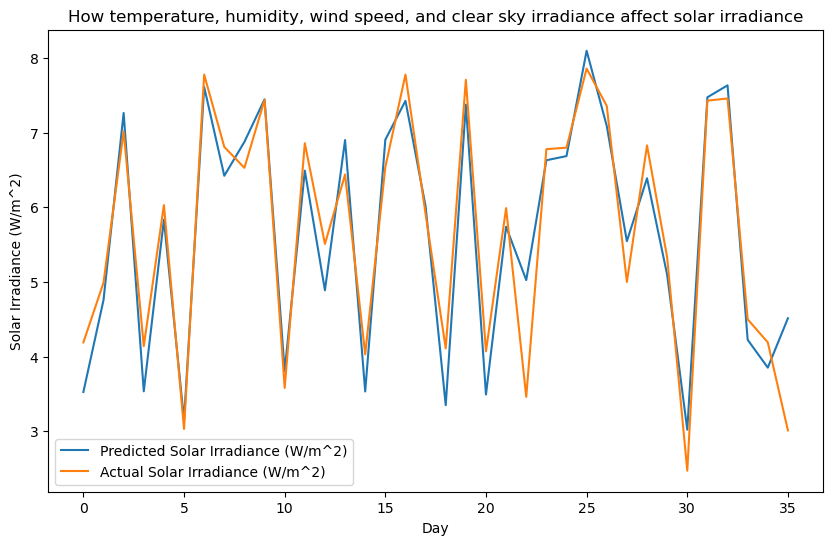

In [7]:
# plot predicted values as a line and actual values as another line
# add the x and y axis labels to show units
# add a title to the plot
plt.figure(figsize=(10, 6))
# add x and y axis labels
plt.xlabel('Day')
plt.ylabel('Solar Irradiance (W/m^2)')
plt.plot(y_pred, label='Predicted Solar Irradiance (W/m^2)')
plt.plot(y_test.values, label='Actual Solar Irradiance (W/m^2)')
plt.legend()
plt.title('How temperature, humidity, wind speed, and clear sky irradiance affect solar irradiance')
plt.show()

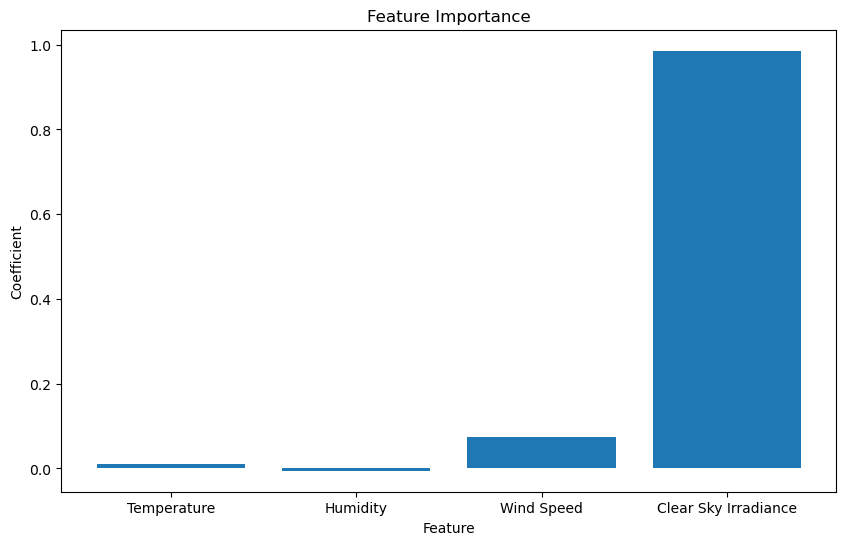

In [16]:
# Feature Importance
# plot the feature importance
plt.figure(figsize=(10, 6))
plt.bar(X.columns, model.coef_)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Feature Importance')
plt.show()
